# 10. Hybrid recommender system

## Purpose

This notebook implements a hybrid recommender using the chronological implicit interaction data.

The hybrid is designed from earlier findings:

- the popularity baseline was robust and covered all users, but had very low personalisation and very narrow catalogue exposure
- the SVD model achieved the strongest personalised ranking quality, but could only score users and items present in the train-fitted latent space
- a practical recommender should preserve SVD strength while providing fallback coverage for unseen users

This notebook builds on earlier phases:

- Phase 04 created modelling-ready datasets
- Phase 05 created chronological train / validation / test splits
- Phase 07 implemented the popularity baseline
- Phase 09 implemented truncated SVD matrix factorisation

## Main tasks

- load chronological implicit train, validation, and test splits
- reuse the train-fitted mapped indices from Phase 5
- fit a truncated SVD model on the training matrix only
- build a train-only popularity reference
- use SVD for mapped users
- use popularity fallback for users not covered by SVD
- optionally blend SVD score and popularity prior for mapped users
- generate Top-N recommendations for validation and test
- exclude items already seen in training
- evaluate ranking quality on validation and test
- analyse routing coverage, novelty, catalogue coverage, and recommendation concentration
- save outputs for later comparison and dashboard use

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import math
import warnings

from scipy import sparse
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

RANDOM_STATE = 42
TOP_N = 20

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
SPLITS_DIR = DATA_DIR / "splits"

TABLES_DIR = PROJECT_ROOT / "outputs" / "tables" / "hybrid"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures" / "hybrid"
LOGS_DIR = PROJECT_ROOT / "outputs" / "logs" / "hybrid"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
LOGS_DIR.mkdir(parents=True, exist_ok=True)

Project root: e:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\notebooks
Splits dir exists: False
Output dir: e:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\notebooks\outputs\tables\hybrid


In [6]:
from __future__ import annotations

import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import MinMaxScaler

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)

## 1. Set project paths

Set project paths and create output subdirectories for the hybrid recommender phase.

In [7]:
PROJECT_ROOT = Path.cwd().resolve().parents[0]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.paths import (
    SPLITS_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    LOGS_DIR,
    ensure_directories,
)

MODEL_NAME = "hybrid"
TOP_K_VALUES = [5, 10, 20]
EXPORT_TOP_N = 10

# Main tunable hyperparameters
N_COMPONENTS = 64
RANDOM_STATE = 42
N_ITER = 10
ALPHA_CANDIDATES = [0.60, 0.70, 0.80, 0.90, 1.00]

TABLES_SUBDIR = TABLES_DIR / MODEL_NAME
FIGURES_SUBDIR = FIGURES_DIR / MODEL_NAME
LOGS_SUBDIR = LOGS_DIR / MODEL_NAME

ensure_directories()
TABLES_SUBDIR.mkdir(parents=True, exist_ok=True)
FIGURES_SUBDIR.mkdir(parents=True, exist_ok=True)
LOGS_SUBDIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Split directory:", SPLITS_DIR)
print("Tables output:", TABLES_SUBDIR)
print("Figures output:", FIGURES_SUBDIR)
print("Logs output:", LOGS_SUBDIR)

Project root: E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project
Split directory: E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\data\splits
Tables output: E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\outputs\tables\hybrid
Figures output: E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\outputs\figures\hybrid
Logs output: E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\outputs\logs\hybrid


## 2. Load implicit chronological splits

The hybrid recommender is built on the implicit interaction split so that it uses the full observed user-recipe interaction history.

These splits were created in Phase 5 and already include train-fitted `user_idx` and `item_idx` columns needed for matrix construction and warm-start scoring.

In [8]:
train_path = SPLITS_DIR / "implicit_train.parquet"
valid_path = SPLITS_DIR / "implicit_valid.parquet"
test_path = SPLITS_DIR / "implicit_test.parquet"

for path in [train_path, valid_path, test_path]:
    print(path, "exists:", path.exists())

implicit_train = pd.read_parquet(train_path).copy()
implicit_valid = pd.read_parquet(valid_path).copy()
implicit_test = pd.read_parquet(test_path).copy()

print("Implicit train shape:", implicit_train.shape)
print("Implicit valid shape:", implicit_valid.shape)
print("Implicit test shape:", implicit_test.shape)

display(implicit_train.head(3))
display(implicit_valid.head(3))
display(implicit_test.head(3))

E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\data\splits\implicit_train.parquet exists: True
E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\data\splits\implicit_valid.parquet exists: True
E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\data\splits\implicit_test.parquet exists: True
Implicit train shape: (792656, 9)
Implicit valid shape: (169855, 9)
Implicit test shape: (169856, 9)


,user_id,recipe_id,date,rating,review_exists,is_unrated_observation,implicit_feedback,user_idx,item_idx
0,2008,992,2000-01-25,5,1,0,1,11,410
1,2008,3603,2000-01-25,4,1,0,1,11,1154
2,2046,517,2000-02-25,5,1,0,1,13,250


,user_id,recipe_id,date,rating,review_exists,is_unrated_observation,implicit_feedback,user_idx,item_idx
0,242205,55768,2010-06-17,5,1,0,1,27992.0,30765.0
1,242729,391308,2010-06-17,5,1,0,1,28058.0,NaN
2,254446,223104,2010-06-17,5,1,0,1,29303.0,118077.0


,user_id,recipe_id,date,rating,review_exists,is_unrated_observation,implicit_feedback,user_idx,item_idx
0,141284,15646,2012-12-28,5,1,0,1,16396.0,7048.0
1,155896,41728,2012-12-28,4,1,0,1,18012.0,22676.0
2,158966,121583,2012-12-28,5,1,0,1,18380.0,68592.0


## 3. Inspect required columns

Confirm that the split datasets contain the columns needed for hybrid recommendation and Top-N evaluation.

In [9]:
required_cols = [
    "user_id",
    "recipe_id",
    "date",
    "implicit_feedback",
    "user_idx",
    "item_idx",
]

for split_name, df in {
    "train": implicit_train,
    "valid": implicit_valid,
    "test": implicit_test,
}.items():
    missing = [c for c in required_cols if c not in df.columns]
    print(split_name, "missing columns:", missing)

print("Train columns:")
print(sorted(implicit_train.columns.tolist()))

train missing columns: []
valid missing columns: []
test missing columns: []
Train columns:
['date', 'implicit_feedback', 'is_unrated_observation', 'item_idx', 'rating', 'recipe_id', 'review_exists', 'user_id', 'user_idx']


## 4. Check mapping coverage and routing eligibility

Validation and test may contain rows whose users or items were not present in the training split mapping.

For the hybrid model:
- rows with known `user_idx` and `item_idx` are eligible for SVD-based scoring
- rows without a known `user_idx` cannot be personalised and therefore require popularity fallback
- rows without a known `item_idx` cannot be part of SVD evaluation truth and are quantified explicitly

In [10]:
def summarise_hybrid_coverage(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    summary = pd.DataFrame(
        [
            {
                "split": split_name,
                "rows": int(len(df)),
                "missing_user_idx": int(df["user_idx"].isna().sum()),
                "missing_item_idx": int(df["item_idx"].isna().sum()),
                "rows_with_both_indices": int(
                    df["user_idx"].notna().mul(df["item_idx"].notna()).sum()
                ),
                "rows_with_user_idx_only": int(
                    df["user_idx"].notna().mul(df["item_idx"].isna()).sum()
                ),
            }
        ]
    )
    summary["rows_evaluable_by_svd_pct"] = round(
        summary["rows_with_both_indices"] / summary["rows"] * 100,
        2,
    )
    summary["rows_with_known_user_pct"] = round(
        (summary["rows_with_both_indices"] + summary["rows_with_user_idx_only"])
        / summary["rows"] * 100,
        2,
    )
    return summary

coverage_summary = pd.concat(
    [
        summarise_hybrid_coverage(implicit_train, "train"),
        summarise_hybrid_coverage(implicit_valid, "valid"),
        summarise_hybrid_coverage(implicit_test, "test"),
    ],
    ignore_index=True,
)

coverage_summary

,split,rows,missing_user_idx,missing_item_idx,rows_with_both_indices,rows_with_user_idx_only,rows_evaluable_by_svd_pct,rows_with_known_user_pct
0,train,792656,0,0,792656,0,100.00,100.00
1,valid,169855,48346,43718,86979,34530,51.21,71.54
2,test,169856,115885,43126,35728,18243,21.03,31.77


## 5. Build evaluable SVD subsets

The SVD model itself still requires both train-known users and train-known items.

These subsets are used for fitting the latent-factor model and for mapped-user evaluation.

The full validation and test splits are still retained separately for hybrid routing analysis.

In [11]:
train_svd = implicit_train[
    implicit_train["user_idx"].notna() & implicit_train["item_idx"].notna()
].copy()

valid_svd = implicit_valid[
    implicit_valid["user_idx"].notna() & implicit_valid["item_idx"].notna()
].copy()

test_svd = implicit_test[
    implicit_test["user_idx"].notna() & implicit_test["item_idx"].notna()
].copy()

for df in [train_svd, valid_svd, test_svd]:
    df["user_idx"] = df["user_idx"].astype(int)
    df["item_idx"] = df["item_idx"].astype(int)

print("Train evaluable shape:", train_svd.shape)
print("Valid evaluable shape:", valid_svd.shape)
print("Test evaluable shape:", test_svd.shape)

Train evaluable shape: (792656, 9)
Valid evaluable shape: (86979, 9)
Test evaluable shape: (35728, 9)


## 6. Build the sparse user-item matrix

Construct the training interaction matrix using the train-fitted mapped user and item indices.

This matrix is the only source used for fitting latent factors.

In [12]:
n_users = int(train_svd["user_idx"].max()) + 1
n_items = int(train_svd["item_idx"].max()) + 1

train_matrix = sparse.csr_matrix(
    (
        train_svd["implicit_feedback"].astype(float).to_numpy(),
        (
            train_svd["user_idx"].to_numpy(),
            train_svd["item_idx"].to_numpy(),
        ),
    ),
    shape=(n_users, n_items),
)

print("Train matrix shape:", train_matrix.shape)
print("Train matrix nnz:", train_matrix.nnz)
print("Matrix density:", train_matrix.nnz / (train_matrix.shape[0] * train_matrix.shape[1]))

Train matrix shape: (106304, 186564)
Train matrix nnz: 792656
Matrix density: 3.996752914369524e-05


In [13]:
svd_model = TruncatedSVD(
    n_components=N_COMPONENTS,
    n_iter=N_ITER,
    random_state=RANDOM_STATE,
)

user_factors = svd_model.fit_transform(train_matrix)
item_factors = svd_model.components_.T

print("User factors shape:", user_factors.shape)
print("Item factors shape:", item_factors.shape)
print("Explained variance ratio sum:", svd_model.explained_variance_ratio_.sum())

User factors shape: (106304, 64)
Item factors shape: (186564, 64)
Explained variance ratio sum: 0.1318843091974922


## 8. Summarise latent-factor fit

,component,explained_variance_ratio,cumulative_explained_variance_ratio
0,1,0.008607,0.008607
1,2,0.006345,0.014952
2,3,0.005212,0.020164
3,4,0.004276,0.024440
4,5,0.003742,0.028182
5,6,0.003434,0.031616
6,7,0.003322,0.034939
7,8,0.003072,0.038011
8,9,0.003000,0.041011
9,10,0.002847,0.043858


,component,explained_variance_ratio,cumulative_explained_variance_ratio
54,55,0.001277,0.120880
55,56,0.001263,0.122143
56,57,0.001253,0.123396
57,58,0.001245,0.124641
58,59,0.001235,0.125876
59,60,0.001229,0.127106
60,61,0.001206,0.128311
61,62,0.001198,0.129509
62,63,0.001193,0.130702
63,64,0.001183,0.131884


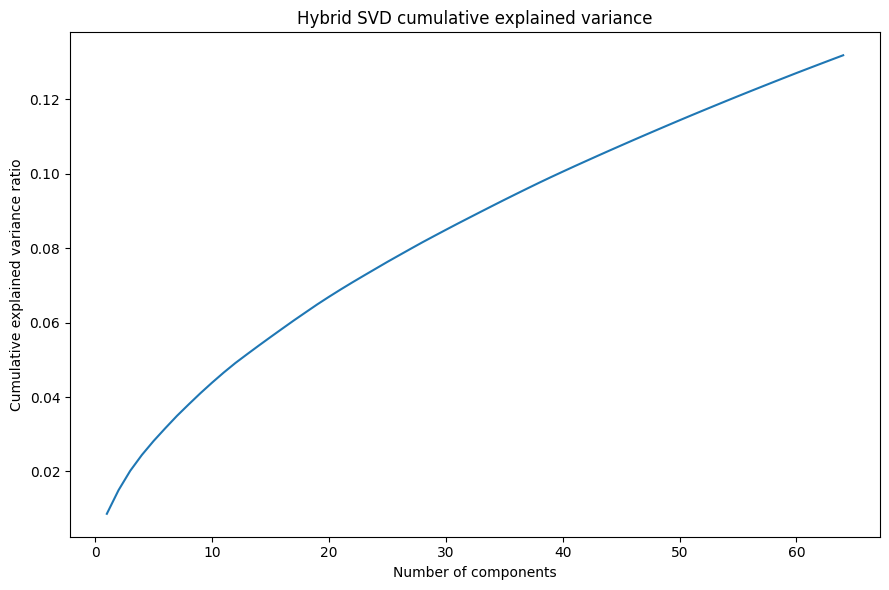

In [14]:
component_summary = pd.DataFrame(
    {
        "component": np.arange(1, len(svd_model.explained_variance_ratio_) + 1),
        "explained_variance_ratio": svd_model.explained_variance_ratio_,
        "cumulative_explained_variance_ratio": np.cumsum(
            svd_model.explained_variance_ratio_
        ),
    }
)

display(component_summary.head(10))
display(component_summary.tail(10))

plt.figure(figsize=(9, 6))
plt.plot(
    component_summary["component"],
    component_summary["cumulative_explained_variance_ratio"],
)
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance ratio")
plt.title("Hybrid SVD cumulative explained variance")
plt.tight_layout()
plt.show()

## 9. Build seen-item lookup from training data

Recommendations should exclude recipes already observed by each user in the training split.

In [15]:
seen_items_by_user = (
    train_svd.groupby("user_idx")["item_idx"]
    .apply(lambda s: set(s.astype(int).tolist()))
    .to_dict()
)

print("Users with seen-item sets:", len(seen_items_by_user))

Users with seen-item sets: 106304


## 10. Build ground-truth lookup for validation and test

For mapped-user Top-N evaluation, each user's relevant items in the holdout split are grouped into sets of interacted recipes.

Only rows with train-known user and item mappings can be evaluated against SVD-generated recommendations.

In [16]:
valid_truth = (
    valid_svd.groupby("user_idx")["item_idx"]
    .apply(lambda s: set(s.astype(int).tolist()))
    .to_dict()
)

test_truth = (
    test_svd.groupby("user_idx")["item_idx"]
    .apply(lambda s: set(s.astype(int).tolist()))
    .to_dict()
)

print("Validation users with mapped ground truth:", len(valid_truth))
print("Test users with mapped ground truth:", len(test_truth))

Validation users with mapped ground truth: 12779
Test users with mapped ground truth: 6048


## 11. Prepare popularity reference from the training split

Popularity from the training split is used in two ways:

- as a fallback recommender for users without train-known mappings
- as a stabilising prior for mapped users through weighted score blending

In [17]:
item_popularity = (
    train_svd.groupby(["item_idx", "recipe_id"])
    .size()
    .reset_index(name="train_interaction_count")
    .sort_values(["train_interaction_count", "item_idx"], ascending=[False, True])
    .reset_index(drop=True)
)

item_popularity["item_popularity_rank"] = np.arange(1, len(item_popularity) + 1)
item_popularity["popularity_score_raw"] = np.log1p(item_popularity["train_interaction_count"])

pop_scaler = MinMaxScaler()
item_popularity["popularity_score"] = pop_scaler.fit_transform(
    item_popularity[["popularity_score_raw"]]
)

popularity_lookup = item_popularity.set_index("item_idx")["train_interaction_count"].to_dict()
popularity_score_lookup = item_popularity.set_index("item_idx")["popularity_score"].to_dict()
recipe_lookup = (
    train_svd[["item_idx", "recipe_id"]]
    .drop_duplicates()
    .set_index("item_idx")["recipe_id"]
    .to_dict()
)

item_popularity.head(10)

,item_idx,recipe_id,train_interaction_count,item_popularity_rank,popularity_score_raw,popularity_score
0,14078,27208,1141,1,7.040536,1.000000
1,49883,89204,1054,2,6.961296,0.987516
2,21107,39087,923,3,6.828712,0.966628
3,17050,32204,911,4,6.815640,0.964569
4,11404,22782,799,5,6.684612,0.943926
5,37647,67256,754,6,6.626718,0.934805
6,29869,54257,725,7,6.587550,0.928634
7,13270,25885,688,8,6.535241,0.920393
8,38583,68955,687,9,6.533789,0.920164
9,14590,28148,672,10,6.511745,0.916692


## 12. Define recommendation and evaluation helpers

Helper functions are created for:

- scoring candidate items for a mapped user
- extracting SVD-based Top-N recommendations
- extracting popularity fallback recommendations
- blending SVD and popularity scores
- computing ranking metrics
- summarising beyond-accuracy measures

In [18]:
def precision_at_k(recommended: list[int], relevant: set[int], k: int) -> float:
    if k == 0:
        return 0.0
    hits = len(set(recommended[:k]) & relevant)
    return hits / k


def recall_at_k(recommended: list[int], relevant: set[int], k: int) -> float:
    if not relevant:
        return 0.0
    hits = len(set(recommended[:k]) & relevant)
    return hits / len(relevant)


def hit_rate_at_k(recommended: list[int], relevant: set[int], k: int) -> float:
    return float(len(set(recommended[:k]) & relevant) > 0)


def dcg_at_k(recommended: list[int], relevant: set[int], k: int) -> float:
    dcg = 0.0
    for rank, item in enumerate(recommended[:k], start=1):
        if item in relevant:
            dcg += 1.0 / math.log2(rank + 1)
    return dcg


def ndcg_at_k(recommended: list[int], relevant: set[int], k: int) -> float:
    if not relevant:
        return 0.0
    ideal_hits = min(len(relevant), k)
    ideal_dcg = sum(1.0 / math.log2(rank + 1) for rank in range(1, ideal_hits + 1))
    if ideal_dcg == 0:
        return 0.0
    return dcg_at_k(recommended, relevant, k) / ideal_dcg


def novelty_at_k(
    recommended: list[int],
    popularity_lookup: dict[int, int],
    total_events: int,
    k: int,
) -> float:
    vals = []
    for item in recommended[:k]:
        pop = popularity_lookup.get(item, 1)
        vals.append(-math.log2(pop / total_events))
    return float(np.mean(vals)) if vals else 0.0


def score_user_all_items(
    user_idx: int,
    user_factors: np.ndarray,
    item_factors: np.ndarray,
) -> np.ndarray:
    return user_factors[user_idx] @ item_factors.T


def recommend_top_n_svd(
    user_idx: int,
    user_factors: np.ndarray,
    item_factors: np.ndarray,
    seen_items_by_user: dict[int, set[int]],
    top_n: int = 10,
) -> tuple[list[int], np.ndarray]:
    scores = score_user_all_items(user_idx, user_factors, item_factors)
    seen = seen_items_by_user.get(user_idx, set())
    if seen:
        scores[list(seen)] = -np.inf
    top_items = np.argpartition(scores, -top_n)[-top_n:]
    top_items = top_items[np.argsort(scores[top_items])[::-1]]
    return top_items.tolist(), scores


def recommend_top_n_popularity(
    user_idx: int,
    seen_items_by_user: dict[int, set[int]],
    top_n: int = 10,
) -> list[int]:
    seen = seen_items_by_user.get(user_idx, set())
    ranked_items = item_popularity["item_idx"].astype(int).tolist()
    if seen:
        ranked_items = [item for item in ranked_items if item not in seen]
    return ranked_items[:top_n]


def recommend_top_n_hybrid_mapped_user(
    user_idx: int,
    alpha: float,
    user_factors: np.ndarray,
    item_factors: np.ndarray,
    seen_items_by_user: dict[int, set[int]],
    top_n: int = 10,
) -> list[int]:
    raw_scores = score_user_all_items(user_idx, user_factors, item_factors).copy()

    seen = seen_items_by_user.get(user_idx, set())
    if seen:
        raw_scores[list(seen)] = -np.inf

    finite_mask = np.isfinite(raw_scores)
    scaled_svd_scores = np.full_like(raw_scores, fill_value=-np.inf, dtype=float)

    if finite_mask.sum() > 0:
        finite_vals = raw_scores[finite_mask]
        min_val = finite_vals.min()
        max_val = finite_vals.max()

        if max_val > min_val:
            scaled_svd_scores[finite_mask] = (finite_vals - min_val) / (max_val - min_val)
        else:
            scaled_svd_scores[finite_mask] = 0.0

    popularity_scores = np.zeros(n_items, dtype=float)
    for item_idx, score in popularity_score_lookup.items():
        popularity_scores[item_idx] = score

    hybrid_scores = alpha * scaled_svd_scores + (1 - alpha) * popularity_scores
    hybrid_scores[~finite_mask] = -np.inf

    top_items = np.argpartition(hybrid_scores, -top_n)[-top_n:]
    top_items = top_items[np.argsort(hybrid_scores[top_items])[::-1]]

    return top_items.tolist()

## 13. Tune hybrid blend weight on validation

The blend parameter `alpha` controls the relative influence of:

- SVD score
- popularity prior

Interpretation:

- `alpha = 1.00` means pure SVD for mapped users
- lower `alpha` values inject more popularity bias and stability

In [19]:
def evaluate_hybrid_on_validation(alpha: float) -> pd.DataFrame:
    rows = []
    total_train_events = int(len(train_svd))
    all_recommended_items = {k: set() for k in TOP_K_VALUES}

    for user_idx, relevant_items in valid_truth.items():
        user_recommendations = recommend_top_n_hybrid_mapped_user(
            user_idx=user_idx,
            alpha=alpha,
            user_factors=user_factors,
            item_factors=item_factors,
            seen_items_by_user=seen_items_by_user,
            top_n=max(TOP_K_VALUES),
        )

        for k in TOP_K_VALUES:
            rec_k = user_recommendations[:k]
            all_recommended_items[k].update(rec_k)

            rows.append(
                {
                    "alpha": alpha,
                    "user_idx": int(user_idx),
                    "k": int(k),
                    "precision_at_k": precision_at_k(rec_k, relevant_items, k),
                    "recall_at_k": recall_at_k(rec_k, relevant_items, k),
                    "hit_rate_at_k": hit_rate_at_k(rec_k, relevant_items, k),
                    "ndcg_at_k": ndcg_at_k(rec_k, relevant_items, k),
                    "novelty_at_k": novelty_at_k(rec_k, popularity_lookup, total_train_events, k),
                }
            )

    user_metric_rows = pd.DataFrame(rows)

    summary_rows = []
    for k in TOP_K_VALUES:
        subset = user_metric_rows[user_metric_rows["k"] == k].copy()
        summary_rows.append(
            {
                "alpha": alpha,
                "k": int(k),
                "users_evaluated": int(subset["user_idx"].nunique()),
                "precision_at_k": subset["precision_at_k"].mean(),
                "recall_at_k": subset["recall_at_k"].mean(),
                "hit_rate_at_k": subset["hit_rate_at_k"].mean(),
                "ndcg_at_k": subset["ndcg_at_k"].mean(),
                "novelty_at_k": subset["novelty_at_k"].mean(),
                "catalog_coverage_at_k": len(all_recommended_items[k]) / n_items,
            }
        )

    return pd.DataFrame(summary_rows)


alpha_tuning_results = pd.concat(
    [evaluate_hybrid_on_validation(alpha) for alpha in ALPHA_CANDIDATES],
    ignore_index=True,
)

display(alpha_tuning_results)

,alpha,k,users_evaluated,precision_at_k,recall_at_k,hit_rate_at_k,ndcg_at_k,novelty_at_k,catalog_coverage_at_k
0,0.6,5,12779,0.008451,0.012077,0.040300,0.012400,10.156393,0.001951
1,0.6,10,12779,0.007489,0.020148,0.066750,0.014997,10.408148,0.003688
2,0.6,20,12779,0.006425,0.033322,0.104938,0.018856,10.728251,0.006673
3,0.7,5,12779,0.008357,0.011786,0.039909,0.012229,10.223129,0.002873
4,0.7,10,12779,0.007364,0.019776,0.065811,0.014761,10.506698,0.005596
5,0.7,20,12779,0.006299,0.032206,0.102355,0.018390,10.854785,0.011090
6,0.8,5,12779,0.008201,0.011285,0.039048,0.011961,10.300927,0.004165
7,0.8,10,12779,0.007223,0.019050,0.064637,0.014404,10.624358,0.008844
8,0.8,20,12779,0.006076,0.030541,0.098756,0.017731,11.005237,0.017565
9,0.9,5,12779,0.008170,0.011221,0.038579,0.011938,10.406288,0.006523


## 14. Select the best validation alpha

In [20]:
alpha_selection = (
    alpha_tuning_results[alpha_tuning_results["k"] == 10]
    .sort_values(
        ["ndcg_at_k", "hit_rate_at_k", "precision_at_k"],
        ascending=False,
    )
    .reset_index(drop=True)
)

BEST_ALPHA = float(alpha_selection.loc[0, "alpha"])

display(alpha_selection)
print("Selected alpha:", BEST_ALPHA)

,alpha,k,users_evaluated,precision_at_k,recall_at_k,hit_rate_at_k,ndcg_at_k,novelty_at_k,catalog_coverage_at_k
0,0.6,10,12779,0.007489,0.020148,0.066750,0.014997,10.408148,0.003688
1,0.7,10,12779,0.007364,0.019776,0.065811,0.014761,10.506698,0.005596
2,0.8,10,12779,0.007223,0.019050,0.064637,0.014404,10.624358,0.008844
3,0.9,10,12779,0.007058,0.018616,0.063229,0.014159,10.771099,0.013582
4,1.0,10,12779,0.006878,0.017778,0.061898,0.013770,10.989532,0.022705


Selected alpha: 0.6


## 15. Evaluate mapped-user hybrid performance on validation and test

This evaluation mirrors the SVD notebook style.

Only users with train-known `user_idx` and relevant train-known `item_idx` holdout data are included in Top-N metric evaluation.

In [21]:
def evaluate_top_n_hybrid(
    truth_lookup: dict[int, set[int]],
    split_name: str,
    top_k_values: list[int],
    alpha: float,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    exported_rows = []
    total_train_events = int(len(train_svd))
    all_recommended_items = {k: set() for k in top_k_values}

    for user_idx, relevant_items in truth_lookup.items():
        user_recommendations = recommend_top_n_hybrid_mapped_user(
            user_idx=user_idx,
            alpha=alpha,
            user_factors=user_factors,
            item_factors=item_factors,
            seen_items_by_user=seen_items_by_user,
            top_n=max(max(top_k_values), EXPORT_TOP_N),
        )

        for rank, item in enumerate(user_recommendations[:EXPORT_TOP_N], start=1):
            exported_rows.append(
                {
                    "split": split_name,
                    "route": "svd_hybrid",
                    "alpha": float(alpha),
                    "user_idx": int(user_idx),
                    "recipe_id": int(recipe_lookup.get(item, -1)),
                    "item_idx": int(item),
                    "rank": int(rank),
                }
            )

        for k in top_k_values:
            rec_k = user_recommendations[:k]
            all_recommended_items[k].update(rec_k)

            rows.append(
                {
                    "split": split_name,
                    "user_idx": int(user_idx),
                    "k": int(k),
                    "precision_at_k": precision_at_k(rec_k, relevant_items, k),
                    "recall_at_k": recall_at_k(rec_k, relevant_items, k),
                    "hit_rate_at_k": hit_rate_at_k(rec_k, relevant_items, k),
                    "ndcg_at_k": ndcg_at_k(rec_k, relevant_items, k),
                    "novelty_at_k": novelty_at_k(rec_k, popularity_lookup, total_train_events, k),
                    "relevant_count": int(len(relevant_items)),
                }
            )

    user_metric_rows = pd.DataFrame(rows)
    recommendation_export = pd.DataFrame(exported_rows)

    summary_rows = []
    for k in top_k_values:
        subset = user_metric_rows[user_metric_rows["k"] == k].copy()

        summary_rows.append(
            {
                "split": split_name,
                "k": int(k),
                "alpha": float(alpha),
                "users_evaluated": int(subset["user_idx"].nunique()),
                "precision_at_k": subset["precision_at_k"].mean(),
                "recall_at_k": subset["recall_at_k"].mean(),
                "hit_rate_at_k": subset["hit_rate_at_k"].mean(),
                "ndcg_at_k": subset["ndcg_at_k"].mean(),
                "novelty_at_k": subset["novelty_at_k"].mean(),
                "catalog_coverage_at_k": len(all_recommended_items[k]) / n_items,
                "recommendation_count": int(subset["user_idx"].nunique() * k),
            }
        )

    metrics_summary = pd.DataFrame(summary_rows)
    return metrics_summary, recommendation_export

## 16. Run validation and test mapped-user evaluation

In [22]:
valid_metrics, valid_recommendations = evaluate_top_n_hybrid(
    truth_lookup=valid_truth,
    split_name="valid",
    top_k_values=TOP_K_VALUES,
    alpha=BEST_ALPHA,
)

test_metrics, test_recommendations = evaluate_top_n_hybrid(
    truth_lookup=test_truth,
    split_name="test",
    top_k_values=TOP_K_VALUES,
    alpha=BEST_ALPHA,
)

hybrid_metrics = pd.concat([valid_metrics, test_metrics], ignore_index=True)

display(hybrid_metrics)
display(valid_recommendations.head(20))
display(test_recommendations.head(20))

,split,k,alpha,users_evaluated,precision_at_k,recall_at_k,hit_rate_at_k,ndcg_at_k,novelty_at_k,catalog_coverage_at_k,recommendation_count
0,valid,5,0.6,12779,0.008451,0.012077,0.040300,0.012400,10.156393,0.001951,63895
1,valid,10,0.6,12779,0.007489,0.020148,0.066750,0.014997,10.408148,0.003688,127790
2,valid,20,0.6,12779,0.006425,0.033322,0.104938,0.018856,10.728251,0.006673,255580
3,test,5,0.6,6048,0.006581,0.010690,0.030754,0.009968,10.156487,0.001485,30240
4,test,10,0.6,6048,0.005407,0.016716,0.048611,0.011746,10.408685,0.002900,60480
5,test,20,0.6,6048,0.004687,0.025540,0.077050,0.014388,10.727231,0.005274,120960


,split,route,alpha,user_idx,recipe_id,item_idx,rank
0,valid,svd_hybrid,0.6,1,32204,17050,1
1,valid,svd_hybrid,0.6,1,22782,11404,2
2,valid,svd_hybrid,0.6,1,25885,13270,3
3,valid,svd_hybrid,0.6,1,77397,43197,4
4,valid,svd_hybrid,0.6,1,108522,61267,5
5,valid,svd_hybrid,0.6,1,67256,37647,6
6,valid,svd_hybrid,0.6,1,15411,6913,7
7,valid,svd_hybrid,0.6,1,95222,53458,8
8,valid,svd_hybrid,0.6,1,71373,39938,9
9,valid,svd_hybrid,0.6,1,32614,17302,10


,split,route,alpha,user_idx,recipe_id,item_idx,rank
0,test,svd_hybrid,0.6,1,32204,17050,1
1,test,svd_hybrid,0.6,1,22782,11404,2
2,test,svd_hybrid,0.6,1,25885,13270,3
3,test,svd_hybrid,0.6,1,77397,43197,4
4,test,svd_hybrid,0.6,1,108522,61267,5
5,test,svd_hybrid,0.6,1,67256,37647,6
6,test,svd_hybrid,0.6,1,15411,6913,7
7,test,svd_hybrid,0.6,1,95222,53458,8
8,test,svd_hybrid,0.6,1,71373,39938,9
9,test,svd_hybrid,0.6,1,32614,17302,10


## 17. Add recipe identifiers and popularity metadata to recommendation exports

In [23]:
recipe_meta = (
    train_svd[["recipe_id", "item_idx"]]
    .drop_duplicates()
    .merge(
        item_popularity[
            ["item_idx", "train_interaction_count", "item_popularity_rank", "popularity_score"]
        ],
        on="item_idx",
        how="left",
    )
)

valid_recommendations_export = valid_recommendations.merge(
    recipe_meta,
    on=["recipe_id", "item_idx"],
    how="left",
)

test_recommendations_export = test_recommendations.merge(
    recipe_meta,
    on=["recipe_id", "item_idx"],
    how="left",
)

display(valid_recommendations_export.head(10))

,split,route,alpha,user_idx,recipe_id,item_idx,rank,train_interaction_count,item_popularity_rank,popularity_score
0,valid,svd_hybrid,0.6,1,32204,17050,1,911,4,0.964569
1,valid,svd_hybrid,0.6,1,22782,11404,2,799,5,0.943926
2,valid,svd_hybrid,0.6,1,25885,13270,3,688,8,0.920393
3,valid,svd_hybrid,0.6,1,77397,43197,4,524,14,0.877566
4,valid,svd_hybrid,0.6,1,108522,61267,5,237,80,0.752927
5,valid,svd_hybrid,0.6,1,67256,37647,6,754,6,0.934805
6,valid,svd_hybrid,0.6,1,15411,6913,7,349,31,0.813687
7,valid,svd_hybrid,0.6,1,95222,53458,8,457,20,0.856056
8,valid,svd_hybrid,0.6,1,71373,39938,9,309,43,0.794567
9,valid,svd_hybrid,0.6,1,32614,17302,10,476,18,0.862460


## 18. Summarise hybrid routing coverage across full validation and test users

This summary is different from mapped-user metric evaluation.

It quantifies how many users in the full split would be handled by:
- SVD-hybrid routing
- popularity fallback routing

based on train-known user availability.

In [24]:
def summarise_user_routing(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    user_level = (
        df.groupby("user_id")["user_idx"]
        .apply(lambda s: s.notna().any())
        .reset_index(name="has_known_user_idx")
    )

    user_level["route"] = np.where(
        user_level["has_known_user_idx"],
        "svd_hybrid",
        "popularity_fallback",
    )
    user_level["split"] = split_name

    summary = (
        user_level.groupby(["split", "route"])
        .size()
        .reset_index(name="users")
    )

    summary["user_share_pct"] = round(summary["users"] / summary["users"].sum() * 100, 2)
    return summary


routing_summary = pd.concat(
    [
        summarise_user_routing(implicit_valid, "valid"),
        summarise_user_routing(implicit_test, "test"),
    ],
    ignore_index=True,
)

routing_summary

,split,route,users,user_share_pct
0,valid,popularity_fallback,32350,70.25
1,valid,svd_hybrid,13697,29.75
2,test,popularity_fallback,90443,93.11
3,test,svd_hybrid,6690,6.89


## 19. Compare validation and test metric profiles

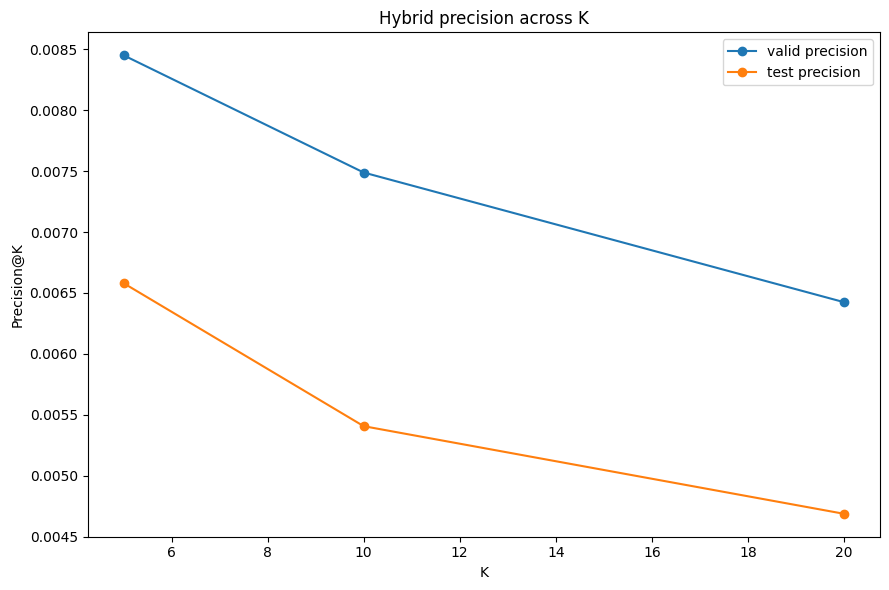

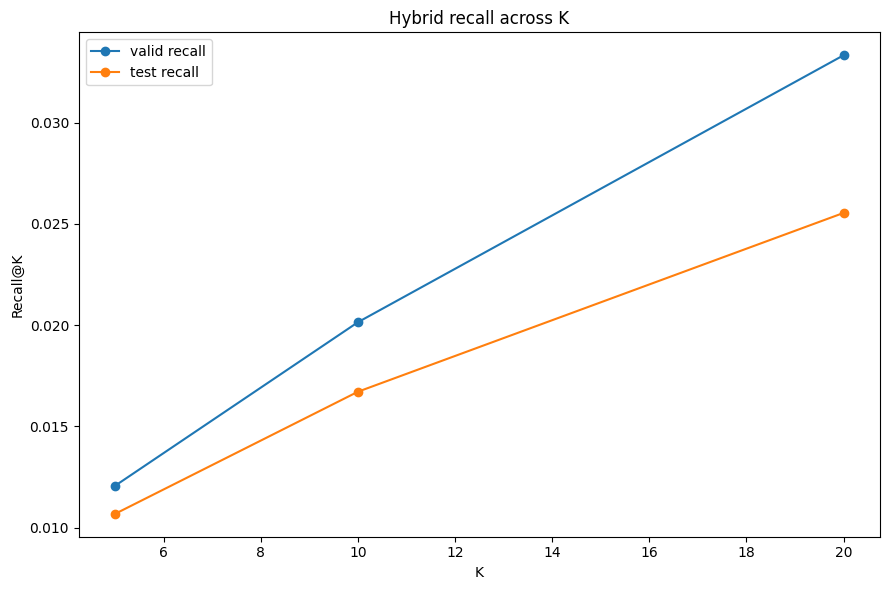

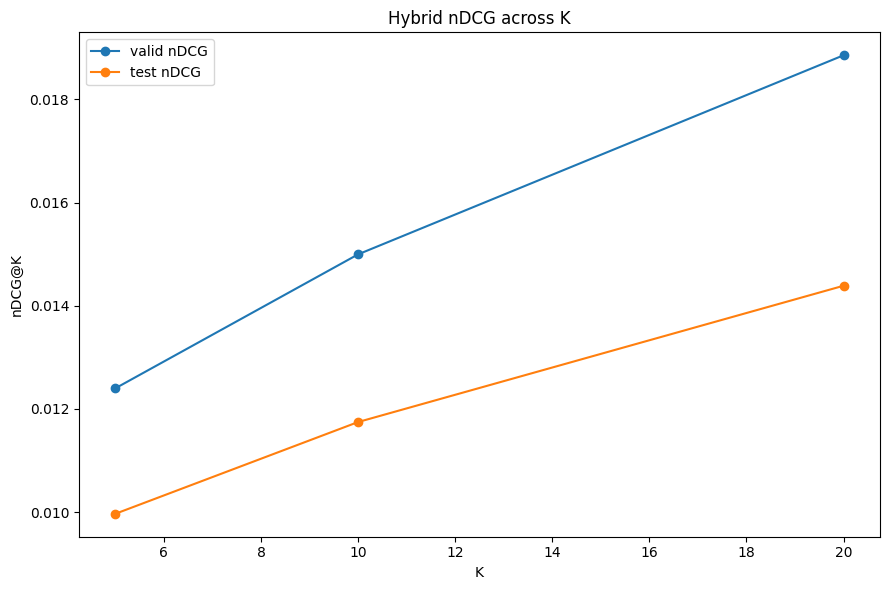

In [25]:
plt.figure(figsize=(9, 6))
for split_name in ["valid", "test"]:
    subset = hybrid_metrics[hybrid_metrics["split"] == split_name].copy()
    plt.plot(subset["k"], subset["precision_at_k"], marker="o", label=f"{split_name} precision")
plt.xlabel("K")
plt.ylabel("Precision@K")
plt.title("Hybrid precision across K")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
for split_name in ["valid", "test"]:
    subset = hybrid_metrics[hybrid_metrics["split"] == split_name].copy()
    plt.plot(subset["k"], subset["recall_at_k"], marker="o", label=f"{split_name} recall")
plt.xlabel("K")
plt.ylabel("Recall@K")
plt.title("Hybrid recall across K")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
for split_name in ["valid", "test"]:
    subset = hybrid_metrics[hybrid_metrics["split"] == split_name].copy()
    plt.plot(subset["k"], subset["ndcg_at_k"], marker="o", label=f"{split_name} nDCG")
plt.xlabel("K")
plt.ylabel("nDCG@K")
plt.title("Hybrid nDCG across K")
plt.legend()
plt.tight_layout()
plt.show()

## 20. Analyse recommendation popularity concentration

Inspect whether the hybrid model still concentrates heavily on already-popular recipes or spreads recommendations more broadly than the popularity baseline.

In [26]:
def build_recommendation_popularity_summary(
    recommendations_df: pd.DataFrame,
    split_name: str,
) -> pd.DataFrame:
    df = recommendations_df.copy()

    summary = (
        df.groupby("item_idx")
        .size()
        .reset_index(name="times_recommended")
        .merge(
            item_popularity[
                ["item_idx", "train_interaction_count", "item_popularity_rank", "popularity_score"]
            ],
            on="item_idx",
            how="left",
        )
        .sort_values("times_recommended", ascending=False)
        .reset_index(drop=True)
    )

    summary["split"] = split_name
    return summary


valid_popularity_summary = build_recommendation_popularity_summary(
    valid_recommendations_export,
    "valid",
)

test_popularity_summary = build_recommendation_popularity_summary(
    test_recommendations_export,
    "test",
)

display(valid_popularity_summary.head(20))
display(test_popularity_summary.head(20))

,item_idx,times_recommended,train_interaction_count,item_popularity_rank,popularity_score,split
0,14590,7721,672,10,0.916692,valid
1,38583,7365,687,9,0.920164,valid
2,38707,7313,661,11,0.914095,valid
3,17050,7118,911,4,0.964569,valid
4,21107,6854,923,3,0.966628,valid
5,11404,6824,799,5,0.943926,valid
6,29869,6723,725,7,0.928634,valid
7,13270,6549,688,8,0.920393,valid
8,37647,6221,754,6,0.934805,valid
9,43197,5989,524,14,0.877566,valid


,item_idx,times_recommended,train_interaction_count,item_popularity_rank,popularity_score,split
0,14590,3652,672,10,0.916692,test
1,38583,3505,687,9,0.920164,test
2,38707,3415,661,11,0.914095,test
3,17050,3322,911,4,0.964569,test
4,11404,3232,799,5,0.943926,test
5,21107,3219,923,3,0.966628,test
6,29869,3179,725,7,0.928634,test
7,13270,3106,688,8,0.920393,test
8,37647,2855,754,6,0.934805,test
9,43197,2827,524,14,0.877566,test


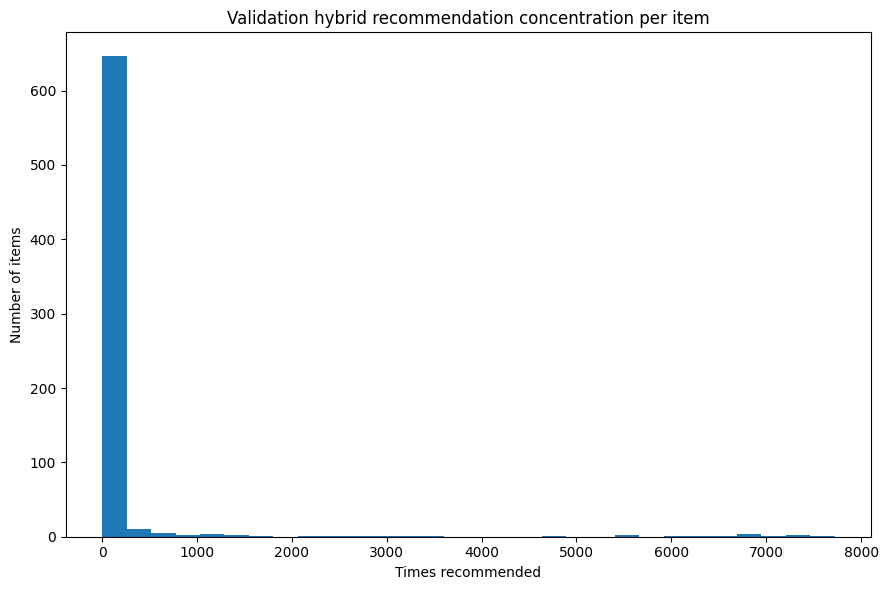

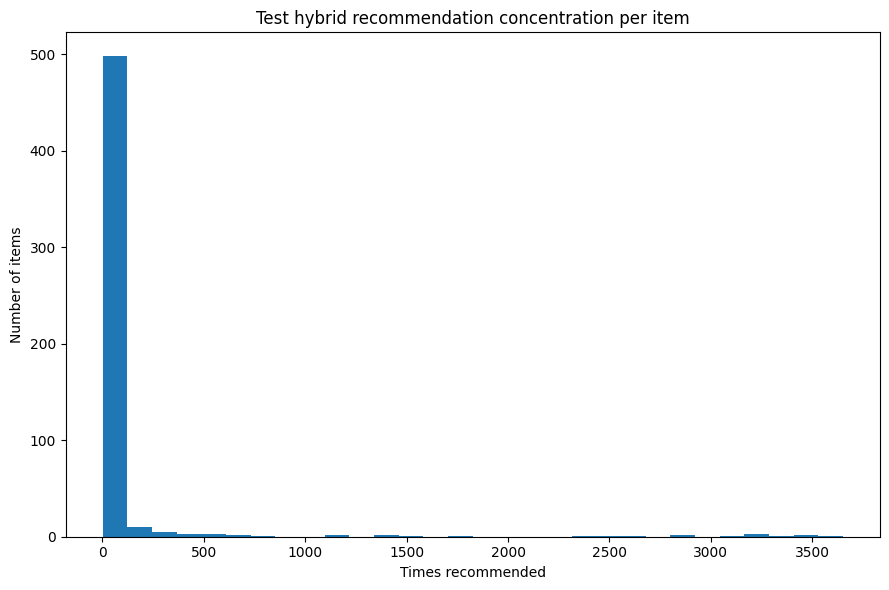

In [27]:
plt.figure(figsize=(9, 6))
plt.hist(valid_popularity_summary["times_recommended"], bins=30)
plt.xlabel("Times recommended")
plt.ylabel("Number of items")
plt.title("Validation hybrid recommendation concentration per item")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
plt.hist(test_popularity_summary["times_recommended"], bins=30)
plt.xlabel("Times recommended")
plt.ylabel("Number of items")
plt.title("Test hybrid recommendation concentration per item")
plt.tight_layout()
plt.show()

## 21. Build a compact run summary

In [28]:
run_summary = {
    "model": "hybrid_recommender",
    "train_rows": int(len(train_svd)),
    "valid_rows_svd_evaluable": int(len(valid_svd)),
    "test_rows_svd_evaluable": int(len(test_svd)),
    "train_users": int(train_svd["user_id"].nunique()),
    "train_items": int(train_svd["recipe_id"].nunique()),
    "matrix_shape": [int(train_matrix.shape[0]), int(train_matrix.shape[1])],
    "matrix_nnz": int(train_matrix.nnz),
    "n_components": int(N_COMPONENTS),
    "n_iter": int(N_ITER),
    "alpha_candidates": ALPHA_CANDIDATES,
    "best_alpha": float(BEST_ALPHA),
    "explained_variance_ratio_sum": float(svd_model.explained_variance_ratio_.sum()),
    "top_k_values": TOP_K_VALUES,
    "routing_summary": routing_summary.to_dict(orient="records"),
    "metrics": hybrid_metrics.to_dict(orient="records"),
}

run_summary

{'model': 'hybrid_recommender',
 'train_rows': 792656,
 'valid_rows_svd_evaluable': 86979,
 'test_rows_svd_evaluable': 35728,
 'train_users': 106304,
 'train_items': 186564,
 'matrix_shape': [106304, 186564],
 'matrix_nnz': 792656,
 'n_components': 64,
 'n_iter': 10,
 'alpha_candidates': [0.6, 0.7, 0.8, 0.9, 1.0],
 'best_alpha': 0.6,
 'explained_variance_ratio_sum': 0.1318843091974922,
 'top_k_values': [5, 10, 20],
 'routing_summary': [{'split': 'valid',
   'route': 'popularity_fallback',
   'users': 32350,
   'user_share_pct': 70.25},
  {'split': 'valid',
   'route': 'svd_hybrid',
   'users': 13697,
   'user_share_pct': 29.75},
  {'split': 'test',
   'route': 'popularity_fallback',
   'users': 90443,
   'user_share_pct': 93.11},
  {'split': 'test',
   'route': 'svd_hybrid',
   'users': 6690,
   'user_share_pct': 6.89}],
 'metrics': [{'split': 'valid',
   'k': 5,
   'alpha': 0.6,
   'users_evaluated': 12779,
   'precision_at_k': 0.008451365521558807,
   'recall_at_k': 0.012076783652437

## 22. Save outputs

In [29]:
coverage_summary.to_csv(
    TABLES_SUBDIR / "10_hybrid_mapping_coverage_summary.csv",
    index=False,
)

component_summary.to_csv(
    TABLES_SUBDIR / "10_hybrid_component_summary.csv",
    index=False,
)

alpha_tuning_results.to_csv(
    TABLES_SUBDIR / "10_hybrid_alpha_tuning.csv",
    index=False,
)

hybrid_metrics.to_csv(
    TABLES_SUBDIR / "10_hybrid_metrics.csv",
    index=False,
)

routing_summary.to_csv(
    TABLES_SUBDIR / "10_hybrid_routing_summary.csv",
    index=False,
)

valid_recommendations_export.to_csv(
    TABLES_SUBDIR / "10_hybrid_valid_recommendations.csv",
    index=False,
)

test_recommendations_export.to_csv(
    TABLES_SUBDIR / "10_hybrid_test_recommendations.csv",
    index=False,
)

valid_popularity_summary.to_csv(
    TABLES_SUBDIR / "10_hybrid_valid_recommendation_popularity.csv",
    index=False,
)

test_popularity_summary.to_csv(
    TABLES_SUBDIR / "10_hybrid_test_recommendation_popularity.csv",
    index=False,
)

with open(LOGS_SUBDIR / "10_hybrid_run_log.json", "w", encoding="utf-8") as f:
    json.dump(run_summary, f, indent=2)

print("Saved hybrid outputs.")

Saved hybrid outputs.


## 23. Final summary

This notebook implemented a hybrid recommender using the chronological implicit training split.

Key modelling decisions in this phase:

- the latent model was fitted on implicit train data only
- train-fitted user and item mappings from Phase 5 were reused
- validation and test rows without train-known mappings were quantified explicitly
- mapped users were scored using a weighted combination of SVD relevance and train popularity prior
- users without train-known mappings were assigned to popularity fallback routing
- recommendations excluded items already seen in training
- evaluation used Top-N ranking metrics on validation and test for mapped users
- routing coverage, catalogue coverage, novelty, and recommendation concentration were also inspected

These outputs are now ready for:

- direct comparison against the popularity baseline
- direct comparison against pure SVD
- dashboard-ready model comparison tables and figures
- final model selection discussion